## 1. Creating a Notebook for running deeper data visualizations on this dataset.

Going to run some additional data visualization code

1. **Creating a dashboard**: Create an interactive dashboard to look at the data more closely
2. **Other random visualizations**: Because why not

A clean start, with a sample data visualization run off of some dummy data to show how the package works. 

Generating sample data...
Sample data shape: (1000, 8)

Creating dataset summary visualization...

Plotting numeric distributions...

Plotting categorical counts...

Plotting boxplots...

Plotting correlation matrix...

Plotting time series...

Plotting heatmap...

All visualizations completed. Close the plot windows to exit.


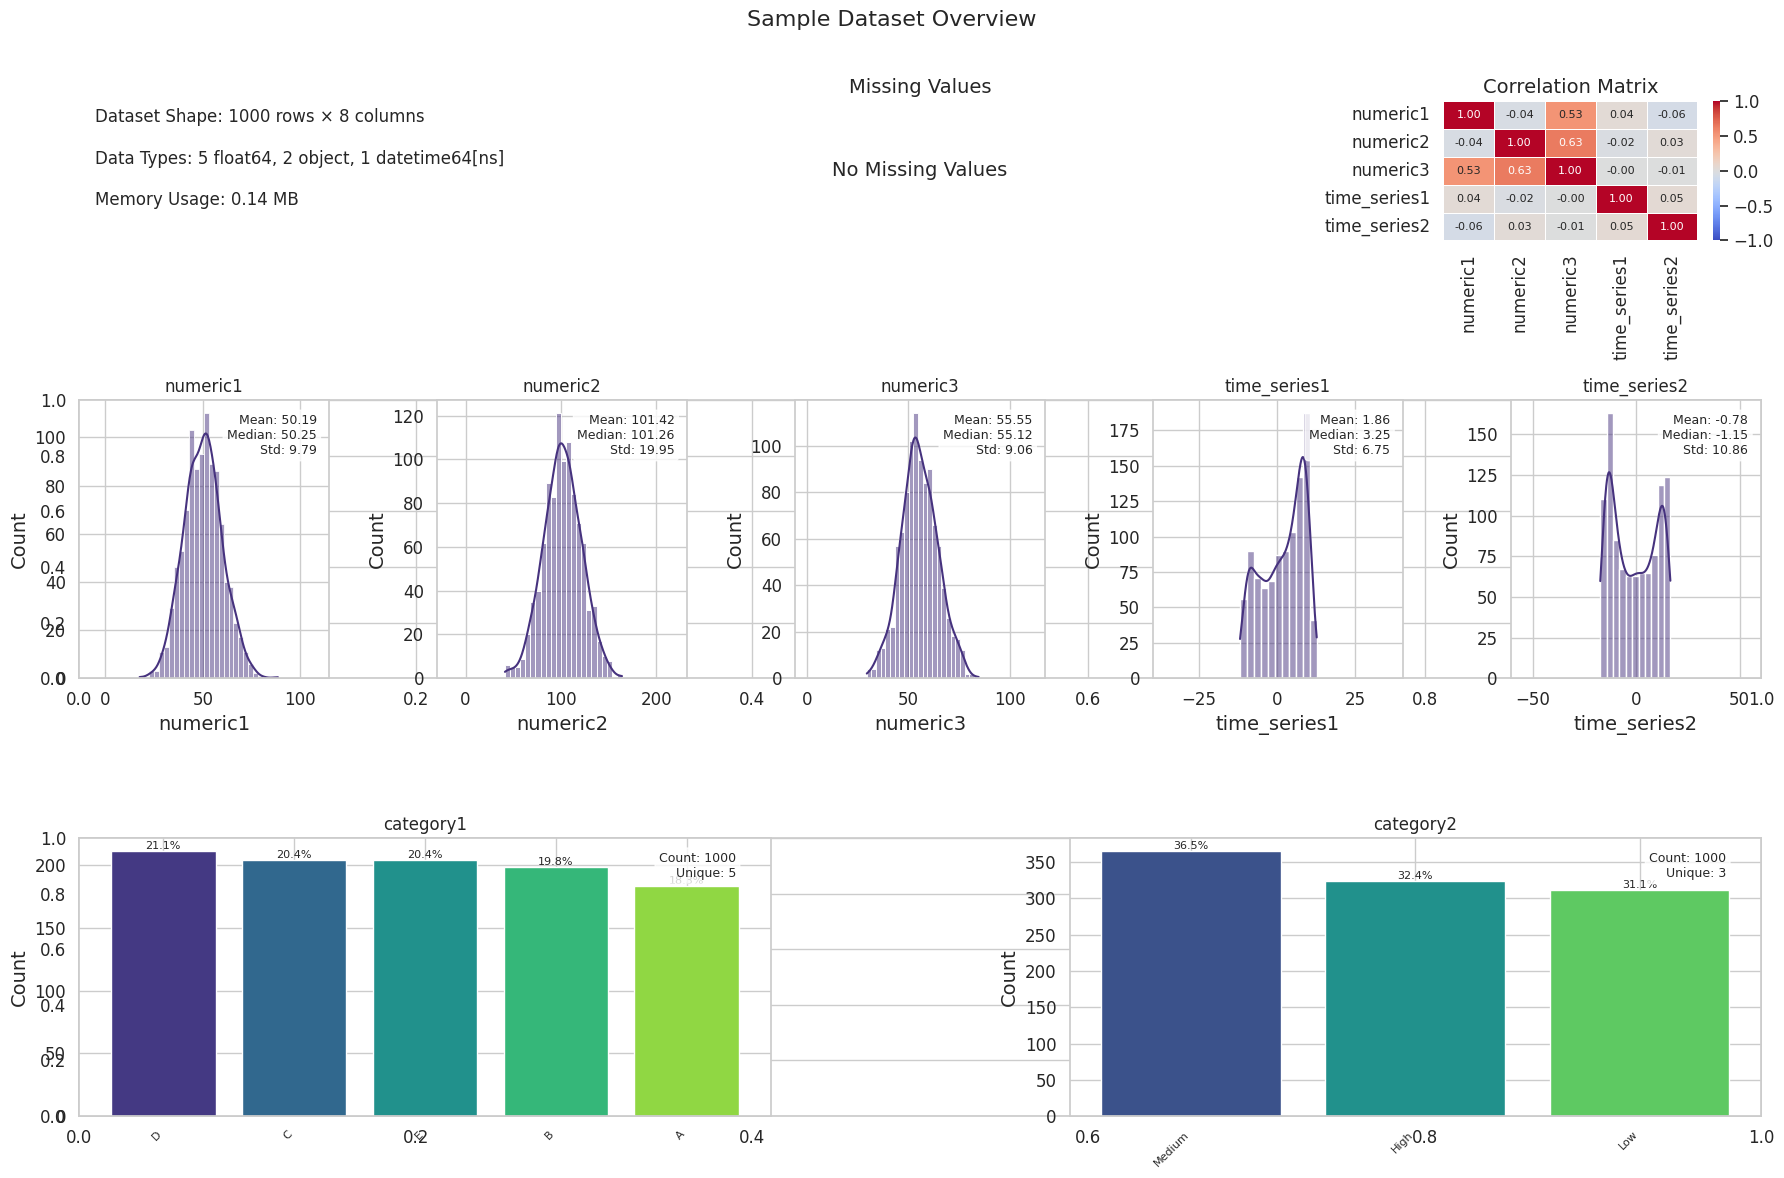

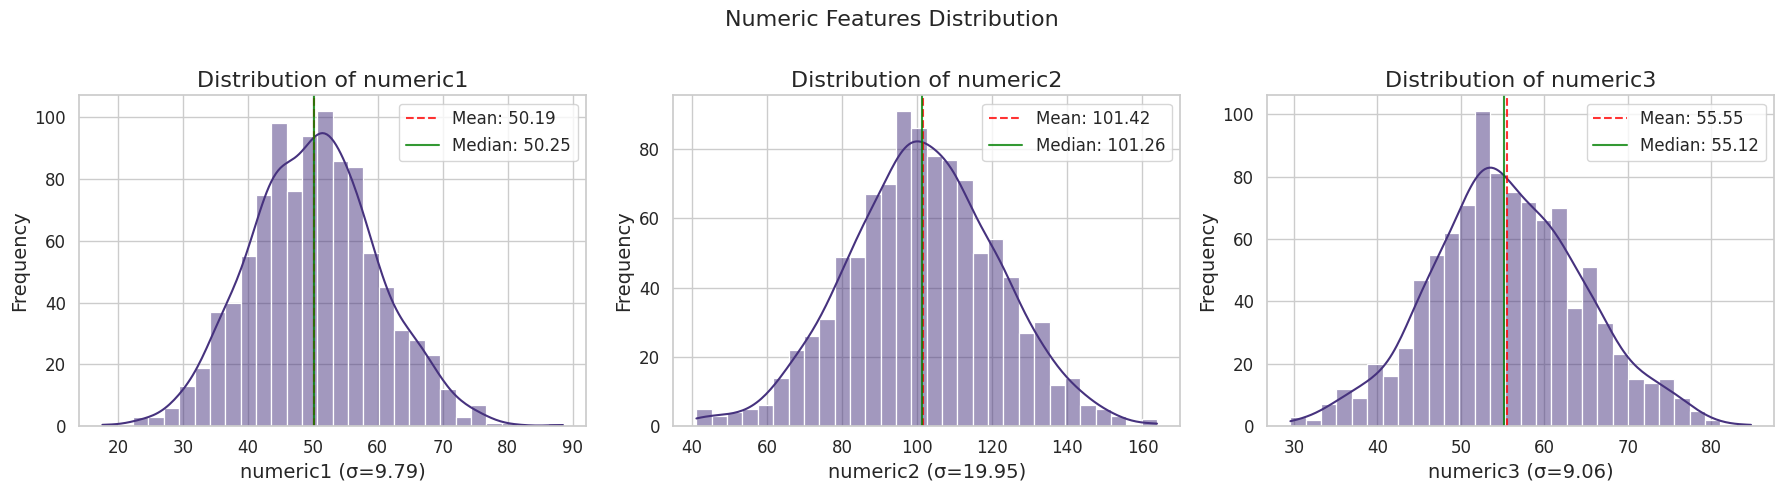

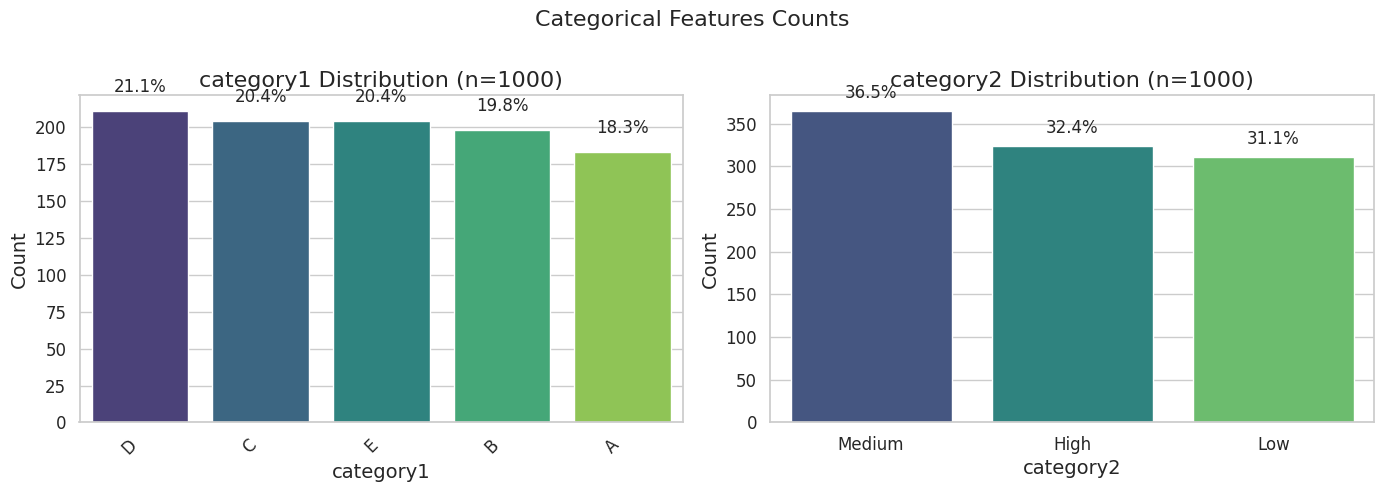

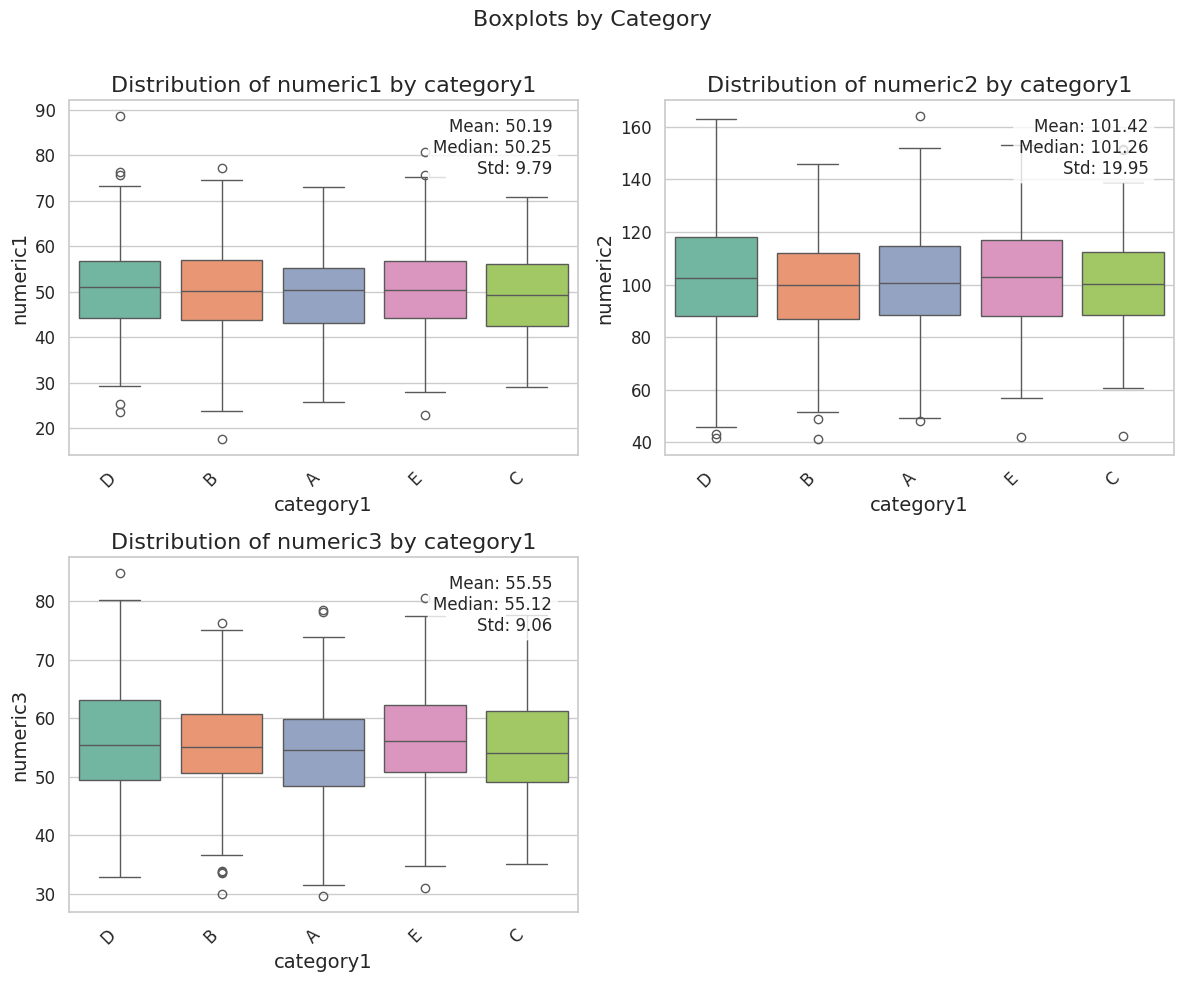

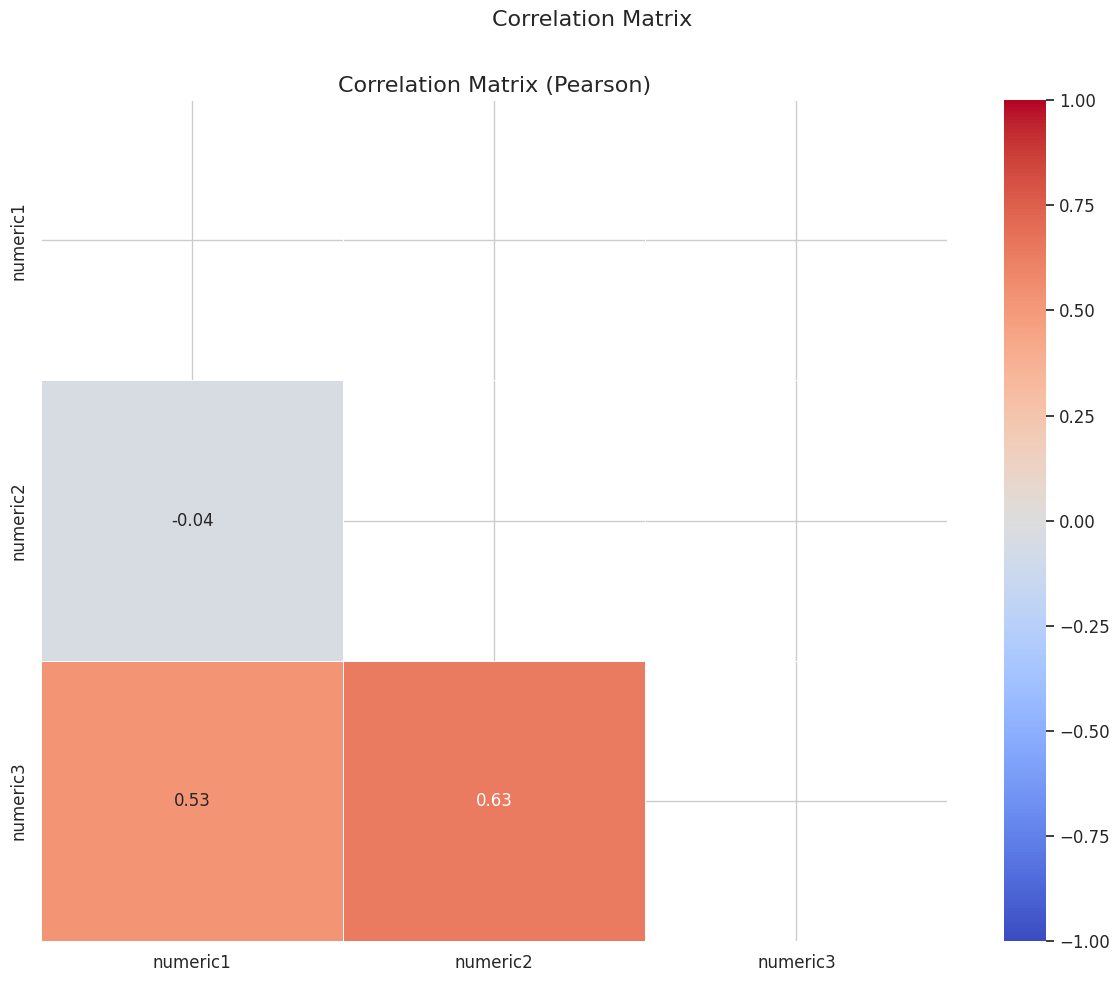

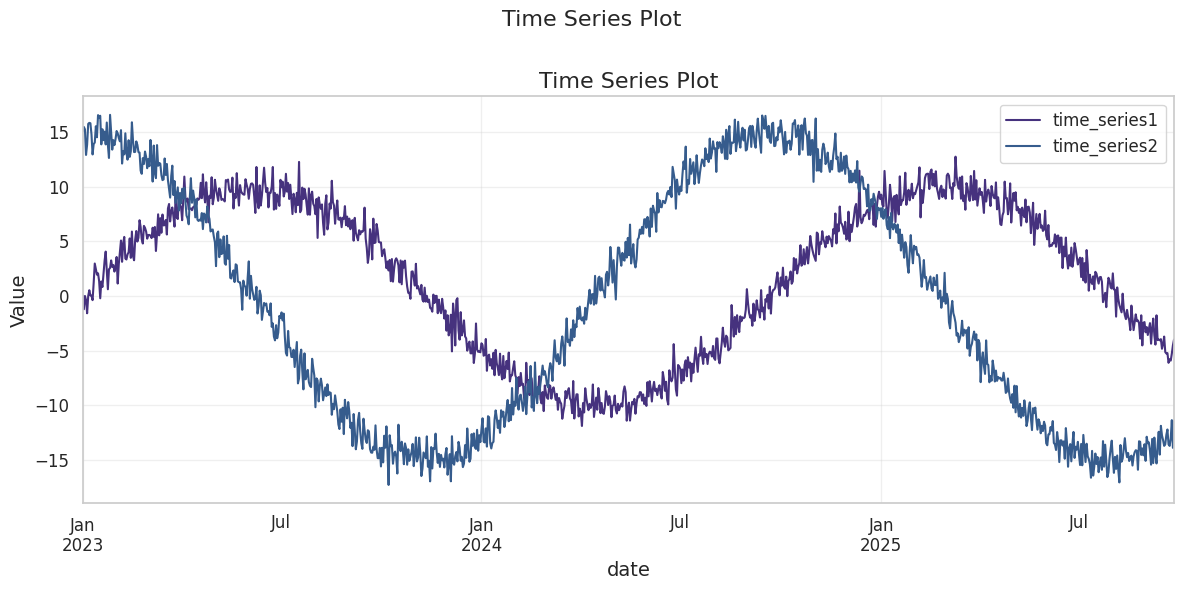

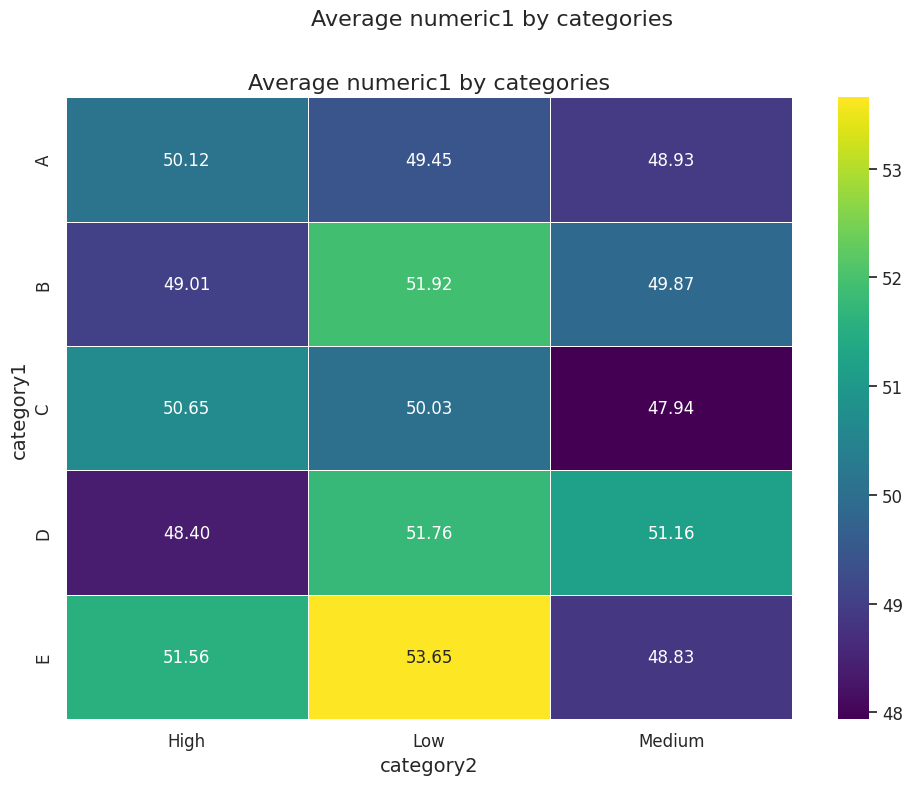

In [2]:
"""
Example usage of the datavis package.

This script demonstrates the various visualization functions
in the datavis package with a sample dataset.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the datavis package
from datavis import (
    set_visualization_style,
    plot_numeric_distribution,
    plot_categorical_counts,
    plot_boxplots,
    plot_correlation_matrix,
    plot_time_series,
    plot_heatmap,
    visualize_dataset_summary
)

# Sample data generation
def generate_sample_data(n_samples=1000):
    """Generate a sample dataset for demonstration"""
    np.random.seed(42)
    
    # Generate dates
    dates = pd.date_range(start='2023-01-01', periods=n_samples, freq='D')
    
    # Generate numeric features
    numeric_feature1 = np.random.normal(loc=50, scale=10, size=n_samples)
    numeric_feature2 = np.random.normal(loc=100, scale=20, size=n_samples)
    numeric_feature3 = numeric_feature1 * 0.5 + numeric_feature2 * 0.3 + np.random.normal(loc=0, scale=5, size=n_samples)
    
    # Generate categorical features
    categories = ['A', 'B', 'C', 'D', 'E']
    categorical_feature1 = np.random.choice(categories, size=n_samples)
    categorical_feature2 = np.random.choice(['High', 'Medium', 'Low'], size=n_samples)
    
    # Create time series
    time_series1 = np.sin(np.linspace(0, 10, n_samples)) * 10 + np.random.normal(0, 1, n_samples)
    time_series2 = np.cos(np.linspace(0, 10, n_samples)) * 15 + np.random.normal(0, 1, n_samples)
    
    # Create DataFrame
    df = pd.DataFrame({
        'date': dates,
        'numeric1': numeric_feature1,
        'numeric2': numeric_feature2,
        'numeric3': numeric_feature3,
        'category1': categorical_feature1,
        'category2': categorical_feature2,
        'time_series1': time_series1,
        'time_series2': time_series2
    })
    
    return df

def main():
    """Main function to demonstrate datavis package functionality"""
    # Set the visualization style
    set_visualization_style(style="whitegrid", context="notebook", palette="viridis")
    
    # Generate sample data
    print("Generating sample data...")
    df = generate_sample_data()
    print(f"Sample data shape: {df.shape}")
    
    # Display dataset summary
    print("\nCreating dataset summary visualization...")
    fig_summary = visualize_dataset_summary(df)
    if fig_summary is not None:
        fig_summary.suptitle("Sample Dataset Overview", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Numeric distributions
    print("\nPlotting numeric distributions...")
    fig_num = plot_numeric_distribution(df, columns=['numeric1', 'numeric2', 'numeric3'])
    if fig_num is not None:
        fig_num.suptitle("Numeric Features Distribution", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Categorical counts
    print("\nPlotting categorical counts...")
    fig_cat = plot_categorical_counts(df, columns=['category1', 'category2'])
    if fig_cat is not None:
        fig_cat.suptitle("Categorical Features Counts", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Boxplots
    print("\nPlotting boxplots...")
    fig_box = plot_boxplots(df, numeric_cols=['numeric1', 'numeric2', 'numeric3'],
                     groupby_col='category1')
    if fig_box is not None:
        fig_box.suptitle("Boxplots by Category", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Correlation matrix
    print("\nPlotting correlation matrix...")
    fig_corr = plot_correlation_matrix(df, columns=['numeric1', 'numeric2', 'numeric3'])
    if fig_corr is not None:
        fig_corr.suptitle("Correlation Matrix", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Time series plot
    print("\nPlotting time series...")
    fig_ts = plot_time_series(df, date_col='date', value_cols=['time_series1', 'time_series2'])
    if fig_ts is not None:
        fig_ts.suptitle("Time Series Plot", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Heatmap
    print("\nPlotting heatmap...")
    # Create a pivot table for the heatmap
    pivot_data = pd.pivot_table(df, values='numeric1', index='category1', 
                           columns='category2', aggfunc='mean')
    
    fig_heat = plot_heatmap(
    data=pivot_data,
    title="Average numeric1 by categories",
    figsize=(10, 8),
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    xticklabels=True,  # Use True to use the default column names
    yticklabels=True,  # Use True to use the default index names
    vmin=None,
    vmax=None,
    save_path=None
    )
    
    if fig_heat is not None:
        fig_heat.suptitle("Average numeric1 by categories", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    print("\nAll visualizations completed. Close the plot windows to exit.")
    plt.show()

if __name__ == "__main__":
    main()

## Now trying to look at our IDR PUF data more deeply

In [4]:
# Load Excel file
file_path = "../data/raw/2023-q1-federal-idr-puf.xlsx"


# Reading in the second sheet
sheet_name = 'OON Emergency and Non-Emergency'
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Display the first few rows to confirm it worked
print(f"Successfully loaded sheet: {sheet_name}")
print(f"Shape of dataframe: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Successfully loaded sheet: OON Emergency and Non-Emergency
Shape of dataframe: (65271, 30)

First 5 rows:


,Dispute Number,DLI Number,Payment Determination Outcome,Default Decision,Type of Dispute,Provider/Facility Group Name,Provider/Facility Name,Provider Email Domain,Provider/Facility NPI Number,Practice/Facility Size,...,Location of Service,Practice/Facility Specialty or Type,Provider/Facility Offer as Percent of QPA,Health Plan/Issuer Offer as Percent of QPA,Offer Selected from Provider or Issuer,Prevailing Party Offer as Percent of QPA,QPA as Percent of Median QPA,Provider/Facility Offer as Percent of Median Provider/Facility Offer Amount,Health Plan/Issuer Offer as Percent of Median Health Plan/Issuer Offer Amount,Prevailing Offer as Percent of Median Prevailing Offer Amount
0,DISP-135724,DLI - 582653,In Favor of Plan/Issuer,No,Single,LONGHORN EMERGENCY MEDICAL ASSOCIATES PA,"BLUDWORTH MD,WHITNEY G",teamhealth.com,1649669672,101-500 Employees,...,TX,EMERGENCY MEDICINE,1.64,1,In Favor of Plan/Issuer,1,1,0.99,1,1
1,DISP-135637,DLI - 582530,In Favor of Plan/Issuer,No,Single,NR,ROXBOROUGH MEMORIAL HOSPITAL,primehealthcare.com,NR,Over 500 Employees,...,PA,ACUTE CARE HOSPITAL,5.13,0.7,In Favor of Plan/Issuer,0.7,1,1,1,1
2,DISP-135495,DLI - 582345,In Favor of Provider/Facility/AA Provider,No,Single,WOODLANDS EMERGENCY PHYSICIANS,WOODLANDS EMERGENCY PHYSICIANS,r1rcm.com,1467989871,51-100 Employees,...,TX,Emergency Provider,3.19,1.15,In Favor of Provider/Facility/AA Provider,3.19,0.27,0.83,0.92,0.88
3,DISP-135654,DLI - 582547,In Favor of Provider/Facility/AA Provider,No,Single,APP OF TENNESSEE ED PLLC,APP OF TENNESSEE ED PLLC,r1rcm.com,1003230236,101-500 Employees,...,TN,EmergencyMedicine,2.47,1.15,In Favor of Provider/Facility/AA Provider,2.47,0.96,0.71,1.15,0.71
4,DISP-135828,DLI - 582852,In Favor of Provider/Facility/AA Provider,No,Batched,Remote Neuromonitoring Physicians PC,Remote Neuromonitoring Physicians PC,specialtycare.net,1124253075,Over 500 Employees,...,PA,Intraoperative Neuromonitoring,11.04,0,In Favor of Provider/Facility/AA Provider,11.04,0.95,1,*,1


In [7]:
# Loading the other sheet from the Excel file
QPA_sheet = 'QPA and Offers'
df_QPA = pd.read_excel('../data/raw/2023-q1-federal-idr-puf.xlsx', sheet_name=QPA_sheet)

# Display basic info about this sheet
print(f"Successfully loaded sheet: {QPA_sheet}")
print(f"Shape of dataframe: {df_QPA.shape}")
print("\nFirst 5 rows of QPA and Offers data:")
df_QPA.head()

Successfully loaded sheet: QPA and Offers
Shape of dataframe: (68007, 9)

First 5 rows of QPA and Offers data:


,Service Code,Place of Service Code,Geographical Region,QPA,Provider/Facility Offer,Health Plan/Issuer Offer,Offer Selected from Provider or Issuer,Prevailing Offer,Default Decision
0,A0436,42.0,"Aberdeen, WA",^,^,^,In Favor of Provider/Facility/AA Provider,^,No
1,A0431,42.0,"Aberdeen, WA",^,^,^,In Favor of Provider/Facility/AA Provider,^,No
2,A0431,42.0,"Aberdeen, WA",^,^,^,In Favor of Provider/Facility/AA Provider,^,No
3,A0431,42.0,"Aberdeen, WA",^,^,^,In Favor of Provider/Facility/AA Provider,^,No
4,A0431,42.0,"Aberdeen, WA",^,^,^,In Favor of Provider/Facility/AA Provider,^,No


In [5]:
# Filter the main dataframe to include only 'Single' cases
# First, let's check the unique values in the "Type of Dispute" column
print("Unique values in 'Type of Dispute' column:")
print(df["Type of Dispute"].unique())

# Now filter for only Single cases
df_single = df[df["Type of Dispute"] == "Single"]
print(f"\nFiltered for Single cases only")
print(f"Original dataframe shape: {df.shape}")
print(f"Filtered dataframe shape: {df_single.shape}")
print(f"Percentage of Single cases: {df_single.shape[0]/df.shape[0]*100:.2f}%")

# Display the first few rows of the filtered data
print("\nFirst 5 rows of filtered data:")
df_single.head()

Unique values in 'Type of Dispute' column:
['Single' 'Batched']

Filtered for Single cases only
Original dataframe shape: (65271, 30)
Filtered dataframe shape: (21917, 30)
Percentage of Single cases: 33.58%

First 5 rows of filtered data:


,Dispute Number,DLI Number,Payment Determination Outcome,Default Decision,Type of Dispute,Provider/Facility Group Name,Provider/Facility Name,Provider Email Domain,Provider/Facility NPI Number,Practice/Facility Size,...,Location of Service,Practice/Facility Specialty or Type,Provider/Facility Offer as Percent of QPA,Health Plan/Issuer Offer as Percent of QPA,Offer Selected from Provider or Issuer,Prevailing Party Offer as Percent of QPA,QPA as Percent of Median QPA,Provider/Facility Offer as Percent of Median Provider/Facility Offer Amount,Health Plan/Issuer Offer as Percent of Median Health Plan/Issuer Offer Amount,Prevailing Offer as Percent of Median Prevailing Offer Amount
0,DISP-135724,DLI - 582653,In Favor of Plan/Issuer,No,Single,LONGHORN EMERGENCY MEDICAL ASSOCIATES PA,"BLUDWORTH MD,WHITNEY G",teamhealth.com,1649669672,101-500 Employees,...,TX,EMERGENCY MEDICINE,1.64,1,In Favor of Plan/Issuer,1,1,0.99,1,1
1,DISP-135637,DLI - 582530,In Favor of Plan/Issuer,No,Single,NR,ROXBOROUGH MEMORIAL HOSPITAL,primehealthcare.com,NR,Over 500 Employees,...,PA,ACUTE CARE HOSPITAL,5.13,0.7,In Favor of Plan/Issuer,0.7,1,1,1,1
2,DISP-135495,DLI - 582345,In Favor of Provider/Facility/AA Provider,No,Single,WOODLANDS EMERGENCY PHYSICIANS,WOODLANDS EMERGENCY PHYSICIANS,r1rcm.com,1467989871,51-100 Employees,...,TX,Emergency Provider,3.19,1.15,In Favor of Provider/Facility/AA Provider,3.19,0.27,0.83,0.92,0.88
3,DISP-135654,DLI - 582547,In Favor of Provider/Facility/AA Provider,No,Single,APP OF TENNESSEE ED PLLC,APP OF TENNESSEE ED PLLC,r1rcm.com,1003230236,101-500 Employees,...,TN,EmergencyMedicine,2.47,1.15,In Favor of Provider/Facility/AA Provider,2.47,0.96,0.71,1.15,0.71
6,DISP-135439,DLI - 582252,In Favor of Provider/Facility/AA Provider,No,Single,EMERGIGROUP PHYS ASSOC PLLC,EMERGIGROUP PHYS ASSOC PLLC,r1rcm.com,1831142769,51-100 Employees,...,TX,Emergency Provider,3.06,1.1,In Favor of Provider/Facility/AA Provider,3.06,0.28,0.83,0.92,0.88


Column 'Dispute Number' has 18131 categories. Showing top 20.
Column 'DLI Number' has 21917 categories. Showing top 20.
Column 'Provider/Facility Group Name' has 1006 categories. Showing top 20.
Column 'Provider/Facility Name' has 2987 categories. Showing top 20.
Column 'Provider Email Domain' has 142 categories. Showing top 20.
Column 'Provider/Facility NPI Number' has 1191 categories. Showing top 20.
Column 'Health Plan/Issuer Name' has 622 categories. Showing top 20.
Column 'Health Plan/Issuer Email Domain' has 156 categories. Showing top 20.
Column 'IDRE Compensation' has 30 categories. Showing top 20.
Column 'Service Code' has 1328 categories. Showing top 20.
Column 'Item or Service Description' has 1235 categories. Showing top 20.
Column 'Location of Service' has 48 categories. Showing top 20.
Column 'Practice/Facility Specialty or Type' has 433 categories. Showing top 20.
Column 'Provider/Facility Offer as Percent of QPA' has 1682 categories. Showing top 20.
Column 'Health Plan/

/workspaces/IDRPublic/datavis/datavis/basic.py:248: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


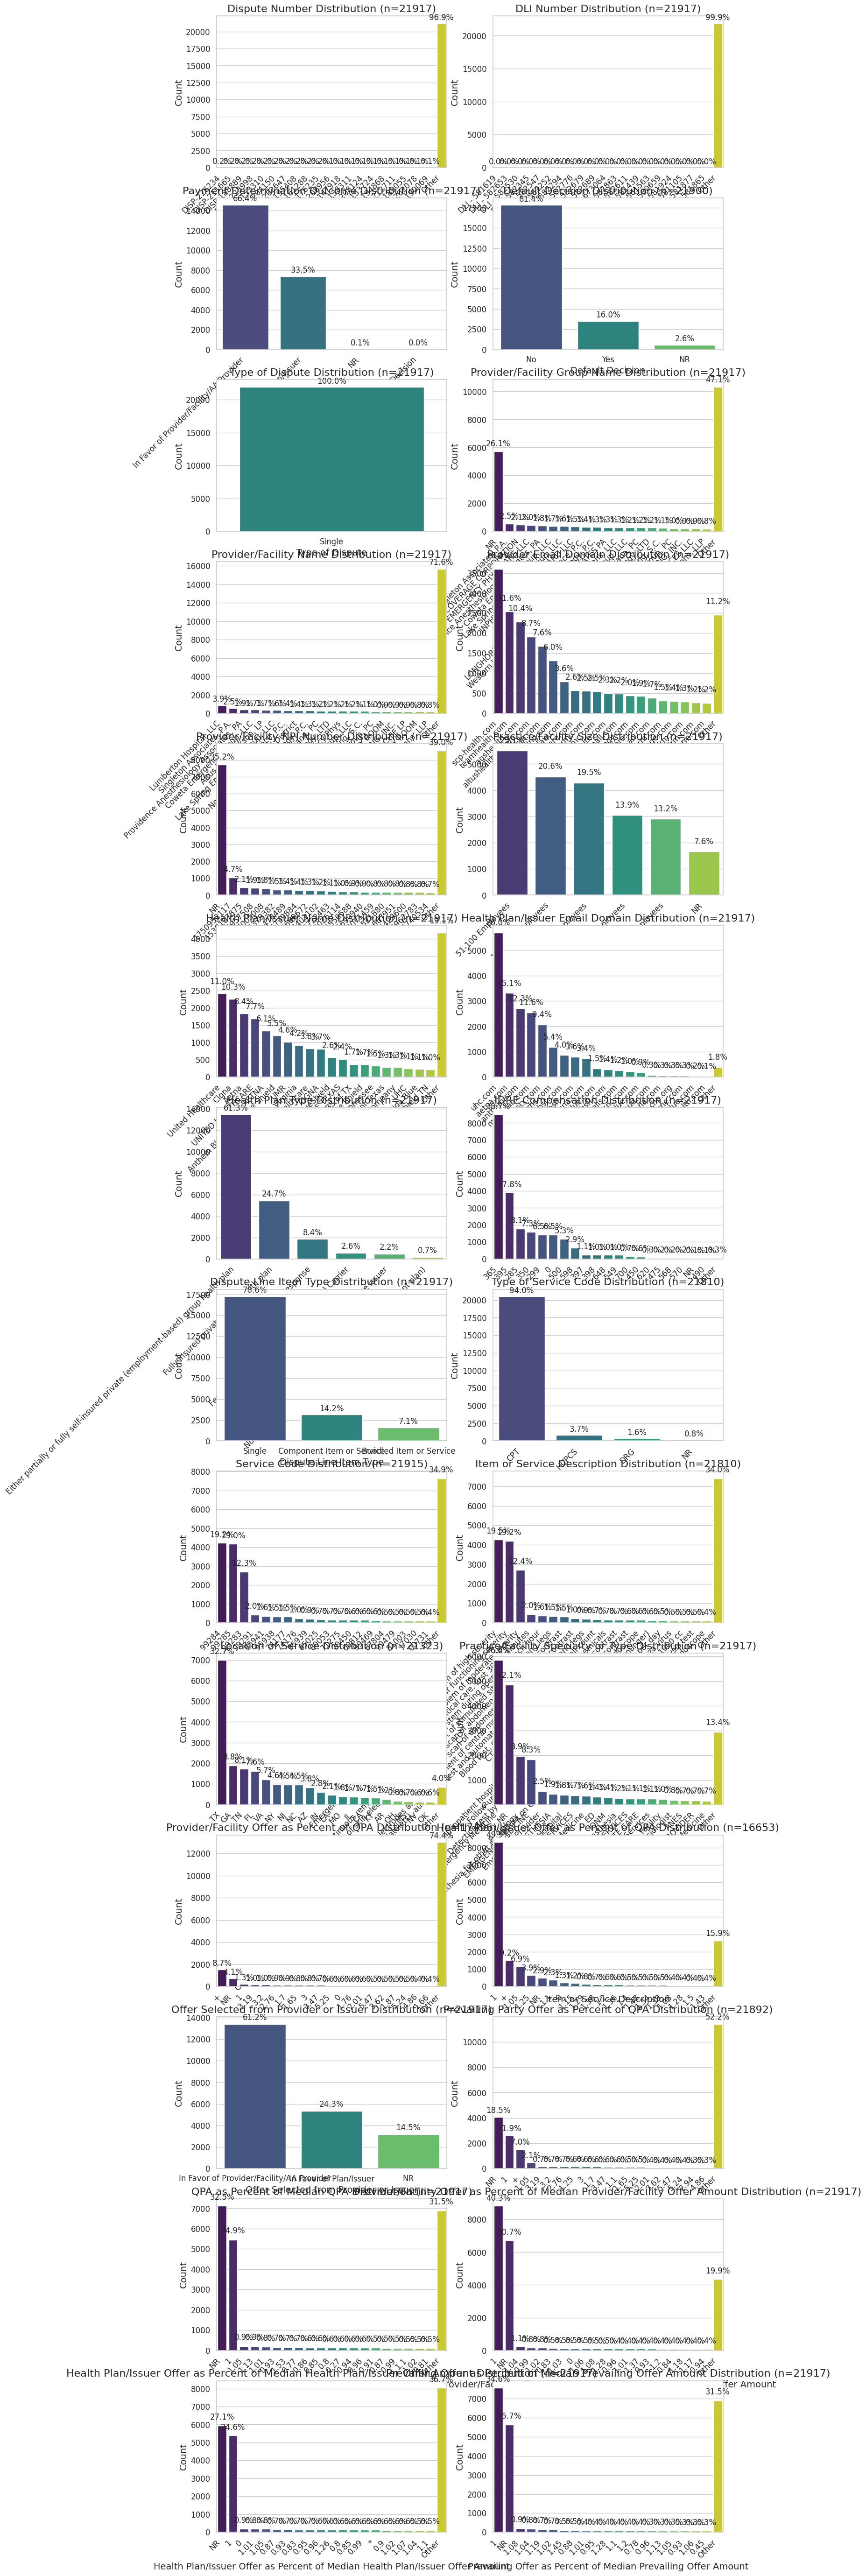

In [9]:
import colorsys
from matplotlib.colors import LinearSegmentedColormap

# Create a dashboard based on our active, main dataframe
cat_plot = plot_categorical_counts(df_single)


In [ ]:

"""
Borrowing from the datavis package.

This script demonstrates the various visualization functions in the datavis package with the PUF IDR dataset.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the datavis package
from datavis import (
    set_visualization_style,
    plot_numeric_distribution,
    plot_categorical_counts,
    plot_boxplots,
    plot_correlation_matrix,
    plot_time_series,
    plot_heatmap,
    visualize_dataset_summary
)

def main():
    """Main function to demonstrate datavis package functionality"""
    # Set the visualization style
    set_visualization_style(style="whitegrid", context="notebook", palette="viridis")

    # First, let's check what columns are available in the DataFrame
    print("Columns in df_single:")
    print(df_single.columns.tolist())

    # Let's also check the data types to identify numeric and categorical columns
    print("\nData types in df_single:")
    print(df_single.dtypes)
    
    # Display dataset summary
    print("\nCreating dataset summary visualization...")
    fig_summary = visualize_dataset_summary(df_single)
    if fig_summary is not None:
        fig_summary.suptitle("IDR Public Use File (PUF) Dataset Overview, Single Cases", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.97])

    # Identify numeric columns
    numeric_cols = df_single.select_dtypes(include=['int64', 'float64']).columns.tolist()
    # Take only the first 3 numeric columns for demonstration if there are more; commenting this one below out for now
    # selected_numeric_cols = numeric_cols[:3] if len(numeric_cols) > 3 else numeric_cols
    # If key numeric columns are known, then "hard code" them directly for this object statement:
    selected_numeric_cols = ['Length of Time to Make Determination']

    # Numeric distributions
    print(f"\nPlotting numeric distributions for columns: {selected_numeric_cols}...")
    if selected_numeric_cols:
        fig_num = plot_numeric_distribution(df_single, columns=selected_numeric_cols)
        if fig_num is not None:
            fig_num.suptitle("Numeric Features Distribution", fontsize=16)
            plt.tight_layout(rect=[0, 0, 1, 0.97])
    else:
        print("No numeric columns found for distribution plots.")
        
    # Identify categorical columns
    categorical_cols = df_single.select_dtypes(include=['object', 'category']).columns.tolist()
    # Take only the first 2 categorical columns for demonstration if there are more
    selected_cat_cols = categorical_cols[:2] if len(categorical_cols) > 2 else categorical_cols
    
    # Categorical counts
    print(f"\nPlotting categorical counts for columns: {selected_cat_cols}...")
    if selected_cat_cols:
        fig_cat = plot_categorical_counts(df_single, columns=selected_cat_cols)
        if fig_cat is not None:
            fig_cat.suptitle("Categorical Features Counts", fontsize=16)
            plt.tight_layout(rect=[0, 0, 1, 0.97])
    else:
        print("No categorical columns found for count plots.")

    # Boxplots
    print("\nPlotting boxplots...")
    if selected_numeric_cols and selected_cat_cols:
        fig_box = plot_boxplots(df_single, numeric_cols=selected_numeric_cols,
                         groupby_col=selected_cat_cols[0])
        if fig_box is not None:
            fig_box.suptitle(f"Boxplots by {selected_cat_cols[0]}", fontsize=16)
            plt.tight_layout(rect=[0, 0, 1, 0.97])
    else:
        print("Not enough columns for boxplots (need at least one numeric and one categorical).")
    
    # Correlation matrix
    print("\nPlotting correlation matrix...")
    if len(selected_numeric_cols) >= 2:
        fig_corr = plot_correlation_matrix(df_single, columns=selected_numeric_cols)
        if fig_corr is not None:
            fig_corr.suptitle("Correlation Matrix", fontsize=16)
            plt.tight_layout(rect=[0, 0, 1, 0.97])
    else:
        print("Not enough numeric columns for correlation matrix (need at least 2).")

    # Check for date columns
    date_cols = [col for col in df_single.columns if 'date' in col.lower() or 
                df_single[col].dtype == 'datetime64[ns]']
    
    # Time series plot
    print("\nPlotting time series...")
    if date_cols and len(selected_numeric_cols) >= 1:
        # Convert date column to datetime if it's not already
        if df_single[date_cols[0]].dtype != 'datetime64[ns]':
            try:
                df_single[date_cols[0]] = pd.to_datetime(df_single[date_cols[0]])
                print(f"Converted {date_cols[0]} to datetime format.")
            except:
                print(f"Could not convert {date_cols[0]} to datetime format.")
                date_cols = []
        
        if date_cols:
            fig_ts = plot_time_series(df_single, date_col=date_cols[0], value_cols=selected_numeric_cols[:2])
            if fig_ts is not None:
                fig_ts.suptitle("Time Series Plot", fontsize=16)
                plt.tight_layout(rect=[0, 0, 1, 0.97])
    else:
        print("No suitable date and numeric columns found for time series plot.")
    
    # Heatmap
    print("\nPlotting heatmap...")
    if len(selected_cat_cols) >= 2 and selected_numeric_cols:
        try:
            # Create a pivot table for the heatmap
            pivot_data = pd.pivot_table(
                df_single, 
                values=selected_numeric_cols[0], 
                index=selected_cat_cols[0], 
                columns=selected_cat_cols[1], 
                aggfunc='mean'
            )
            
            fig_heat = plot_heatmap(
                data=pivot_data,
                title=f"Average {selected_numeric_cols[0]} by {selected_cat_cols[0]} and {selected_cat_cols[1]}",
                figsize=(10, 8),
                cmap="viridis",
                annot=True,
                fmt=".2f",
                linewidths=0.5,
                xticklabels=True,
                yticklabels=True,
                vmin=None,
                vmax=None,
                save_path=None
            )
            
            if fig_heat is not None:
                fig_heat.suptitle(f"Average {selected_numeric_cols[0]} by categories", fontsize=16)
                plt.tight_layout(rect=[0, 0, 1, 0.97])
        except Exception as e:
            print(f"Error creating heatmap: {e}")
    else:
        print("Not enough suitable columns for heatmap (need at least 2 categorical and 1 numeric).")
    
    print("\nAll visualizations completed. Close the plot windows to exit.")
    plt.show()

if __name__ == "__main__":
    main()


Columns in df_single:
['Dispute Number', 'DLI Number', 'Payment Determination Outcome', 'Default Decision', 'Type of Dispute', 'Provider/Facility Group Name', 'Provider/Facility Name', 'Provider Email Domain', 'Provider/Facility NPI Number', 'Practice/Facility Size', 'Health Plan/Issuer Name', 'Health Plan/Issuer Email Domain', 'Health Plan Type', 'Length of Time to Make Determination', 'IDRE Compensation', 'Dispute Line Item Type', 'Type of Service Code', 'Service Code', 'Place of Service Code', 'Item or Service Description', 'Location of Service', 'Practice/Facility Specialty or Type', 'Provider/Facility Offer as Percent of QPA', 'Health Plan/Issuer Offer as Percent of QPA', 'Offer Selected from Provider or Issuer', 'Prevailing Party Offer as Percent of QPA', 'QPA as Percent of Median QPA', 'Provider/Facility Offer as Percent of Median Provider/Facility Offer Amount', 'Health Plan/Issuer Offer as Percent of Median Health Plan/Issuer Offer Amount', 'Prevailing Offer as Percent of Medi

Analyzing the relationship between determination time and IDRE compensation...
Number of unique compensation categories: 30

Top 10 compensation categories by frequency:
- 365: 8491 instances
- 395: 3906 instances
- 285: 1778 instances
- 350: 1590 instances
- 299: 1432 instances
- 0: 1421 instances
- 500: 1166 instances
- 598: 644 instances
- 397: 231 instances
- 398: 230 instances
- Other (combined): 1028 instances
Could not convert compensation to numeric values: Bin labels must be one fewer than the number of bin edges
Will proceed with categorical analysis only.

Performing hierarchical clustering of compensation categories based on determination time...

Formed 5 clusters of compensation categories:


TypeError: sequence item 0: expected str instance, int found

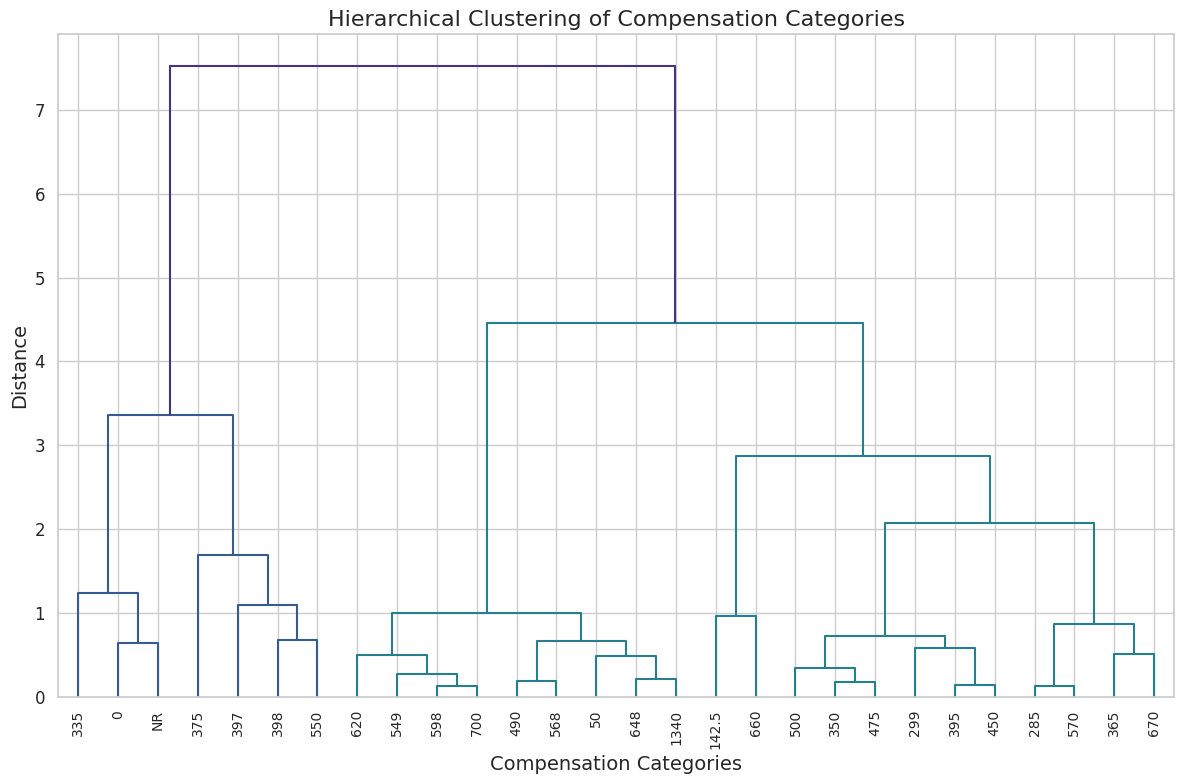

In [6]:
"""
Analysis of Length of Time to Determination vs IDRE Compensation
This script examines the relationship between determination time and compensation amounts,
adapted for handling a large number of compensation categories (40+)
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Import your visualization helpers
from datavis import set_visualization_style

def analyze_time_vs_compensation(df_single):
    """Analyze the relationship between determination time and compensation category"""
    # Set visualization style
    set_visualization_style(style="whitegrid", context="notebook", palette="viridis")
    
    # Ensure your variables have the correct types
    time_col = 'Length of Time to Make Determination'  
    compensation_col = 'IDRE Compensation'  
    
    # Check if columns exist
    if time_col not in df_single.columns or compensation_col not in df_single.columns:
        print(f"Error: Required columns not found. Available columns are: {df_single.columns.tolist()}")
        return
    
    # Make a copy of the dataframe to avoid modifying the original
    analysis_df = df_single.copy()
    
    # Get count of categories
    category_counts = analysis_df[compensation_col].value_counts()
    num_categories = len(category_counts)
    print(f"Number of unique compensation categories: {num_categories}")
    
    # Strategy 1: Group categories by frequency
    # Show only the top N most frequent categories and group the rest as "Other"
    top_n = 10  # Adjust as needed
    top_categories = category_counts.nlargest(top_n).index.tolist()
    
    analysis_df['compensation_grouped'] = analysis_df[compensation_col].apply(
        lambda x: x if x in top_categories else 'Other'
    )
    
    print(f"\nTop {top_n} compensation categories by frequency:")
    for cat in top_categories:
        print(f"- {cat}: {category_counts[cat]} instances")
    
    print(f"- Other (combined): {analysis_df[analysis_df['compensation_grouped'] == 'Other'].shape[0]} instances")
    
    # Strategy 2: Group by compensation amount ranges (if compensation is numeric)
    try:
        # Try to extract numeric values if compensation is in format like "$1,000"
        # This step assumes compensation values can be converted to numeric
        analysis_df['compensation_numeric'] = analysis_df[compensation_col].str.replace('$', '', regex=False)
        analysis_df['compensation_numeric'] = analysis_df['compensation_numeric'].str.replace(',', '', regex=False)
        analysis_df['compensation_numeric'] = pd.to_numeric(analysis_df['compensation_numeric'], errors='coerce')
        
        # Create compensation ranges using qcut (quantile-based discretization)
        n_bins = min(10, num_categories)  # Adjust the number of bins as needed
        analysis_df['compensation_range'] = pd.qcut(
            analysis_df['compensation_numeric'], 
            q=n_bins, 
            duplicates='drop',
            labels=[f'Range {i+1}' for i in range(n_bins)]
        )
        
        # If we successfully created compensation ranges
        print("\nCompensation ranges created based on dollar amounts:")
        range_counts = analysis_df['compensation_range'].value_counts().sort_index()
        range_boundaries = pd.qcut(analysis_df['compensation_numeric'], q=n_bins, duplicates='drop').unique()
        
        for i, (range_label, count) in enumerate(range_counts.items()):
            range_min = range_boundaries[i].left
            range_max = range_boundaries[i].right
            print(f"- {range_label}: ${range_min:.2f} to ${range_max:.2f} ({count} instances)")
        
        has_numeric_compensation = True
    except Exception as e:
        print(f"Could not convert compensation to numeric values: {e}")
        print("Will proceed with categorical analysis only.")
        has_numeric_compensation = False
    
    # Strategy 3: Hierarchical clustering of categories based on determination time
    print("\nPerforming hierarchical clustering of compensation categories based on determination time...")
    
    # Calculate mean and standard deviation of time for each category
    category_stats = analysis_df.groupby(compensation_col)[time_col].agg(['mean', 'std', 'count']).reset_index()
    # Filter out categories with too few samples (optional)
    min_samples = 3  # Adjust as needed
    category_stats = category_stats[category_stats['count'] >= min_samples]
    
    if len(category_stats) < 2:
        print("Not enough categories with sufficient samples for clustering.")
    else:
        # Prepare features for clustering (mean and std of time)
        features = category_stats[['mean', 'std']].values
        # Standardize features
        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)
        
        # Perform hierarchical clustering
        Z = linkage(features_scaled, method='ward')
        
        # Plot dendrogram
        plt.figure(figsize=(12, 8))
        plt.title('Hierarchical Clustering of Compensation Categories')
        dendrogram(
            Z,
            labels=category_stats[compensation_col].values,
            leaf_rotation=90,
            leaf_font_size=10
        )
        plt.xlabel('Compensation Categories')
        plt.ylabel('Distance')
        plt.tight_layout()
        
        # Form clusters
        n_clusters = min(5, len(category_stats))  # Adjust as needed
        cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')
        
        category_stats['cluster'] = cluster_labels
        print(f"\nFormed {n_clusters} clusters of compensation categories:")
        for cluster_id in range(1, n_clusters + 1):
            cluster_members = category_stats[category_stats['cluster'] == cluster_id][compensation_col].tolist()
            print(f"- Cluster {cluster_id}: {', '.join(cluster_members)}")
        
        # Add cluster information to the main dataframe
        cluster_map = dict(zip(category_stats[compensation_col], category_stats['cluster']))
        analysis_df['compensation_cluster'] = analysis_df[compensation_col].map(cluster_map)
    
    # Create visualizations based on the grouping strategies
    figs = []
    
    # 1. Box plot with top categories
    fig1 = plt.figure(figsize=(15, 10))
    ax1 = fig1.add_subplot(1, 1, 1)
    sns.boxplot(x='compensation_grouped', y=time_col, data=analysis_df, ax=ax1)
    ax1.set_title('Box Plot: Determination Time by Top Compensation Categories')
    ax1.set_xlabel('Compensation Category')
    ax1.set_ylabel('Time to Determination')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    figs.append(fig1)
    
    # 2. If we have numeric compensation, create a scatter plot
    if has_numeric_compensation:
        fig2 = plt.figure(figsize=(12, 8))
        ax2 = fig2.add_subplot(1, 1, 1)
        sns.scatterplot(x='compensation_numeric', y=time_col, data=analysis_df, ax=ax2, alpha=0.6)
        # Add regression line
        sns.regplot(x='compensation_numeric', y=time_col, data=analysis_df, ax=ax2, 
                    scatter=False, line_kws={"color": "red"})
        ax2.set_title('Scatter Plot: Determination Time vs. Compensation Amount')
        ax2.set_xlabel('Compensation Amount ($)')
        ax2.set_ylabel('Time to Determination')
        plt.tight_layout()
        figs.append(fig2)
        
        # 3. Bar plot with error bars by compensation range
        fig3 = plt.figure(figsize=(14, 8))
        ax3 = fig3.add_subplot(1, 1, 1)
        # Calculate statistics for the bar plot
        bar_data = analysis_df.groupby('compensation_range')[time_col].agg(['mean', 'count', 'std']).reset_index()
        # Calculate 95% confidence interval
        bar_data['ci'] = 1.96 * bar_data['std'] / np.sqrt(bar_data['count'])
        
        # Sort by compensation range
        bar_data = bar_data.sort_index()
        
        # Plot
        sns.barplot(x='compensation_range', y='mean', data=bar_data, ax=ax3)
        # Add error bars
        ax3.errorbar(x=range(len(bar_data)), y=bar_data['mean'], yerr=bar_data['ci'], 
                    fmt='none', c='black', capsize=5)
        ax3.set_title('Mean Determination Time by Compensation Range with 95% CI')
        ax3.set_xlabel('Compensation Range')
        ax3.set_ylabel('Mean Time to Determination')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        figs.append(fig3)
    
    # 4. If we performed clustering, show boxplot by cluster
    if 'compensation_cluster' in analysis_df.columns:
        fig4 = plt.figure(figsize=(12, 8))
        ax4 = fig4.add_subplot(1, 1, 1)
        sns.boxplot(x='compensation_cluster', y=time_col, data=analysis_df, ax=ax4)
        ax4.set_title('Box Plot: Determination Time by Compensation Category Cluster')
        ax4.set_xlabel('Compensation Cluster')
        ax4.set_ylabel('Time to Determination')
        plt.tight_layout()
        figs.append(fig4)
    
    # 5. Create a heatmap of correlation between time and compensation if numeric
    if has_numeric_compensation:
        # First check if there's a correlation
        correlation = analysis_df[[time_col, 'compensation_numeric']].corr().iloc[0, 1]
        print(f"\nPearson correlation between determination time and compensation amount: {correlation:.4f}")
        
        # Determine if correlation is significant
        if len(analysis_df) >= 10:  # Need at least a few data points for meaningful test
            corr_pvalue = stats.pearsonr(
                analysis_df[time_col].dropna(), 
                analysis_df['compensation_numeric'].dropna()
            )[1]
            print(f"Correlation p-value: {corr_pvalue:.4f}")
            
            if corr_pvalue < 0.05:
                print("The correlation is statistically significant.")
            else:
                print("The correlation is not statistically significant.")
    
    # 6. Perform ANOVA on the grouped categories
    print("\nPerforming one-way ANOVA test on grouped categories:")
    try:
        # Create a linear model
        model = ols(f'{time_col} ~ C(compensation_grouped)', data=analysis_df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        print(anova_table)
        
        # Interpret the p-value
        p_value = anova_table['PR(>F)'][0]
        alpha = 0.05
        if p_value < alpha:
            print(f"\nANOVA Result: There is a statistically significant difference in determination time between compensation categories (p={p_value:.4f}).")
        else:
            print(f"\nANOVA Result: There is no statistically significant difference in determination time between compensation categories (p={p_value:.4f}).")
    except Exception as e:
        print(f"Error performing ANOVA: {e}")
    
    return figs

def main():
    # We'll assume df_single is already defined from your previous code
    
    print("Analyzing the relationship between determination time and IDRE compensation...")
    figs = analyze_time_vs_compensation(df_single)
    
    plt.show()
    print("\nAnalysis completed.")

if __name__ == "__main__":
    main()